In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr 

In [2]:
from datetime import datetime, timedelta

In [5]:
ds = xr.open_dataset("/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/dataset/test_case/output.nc")

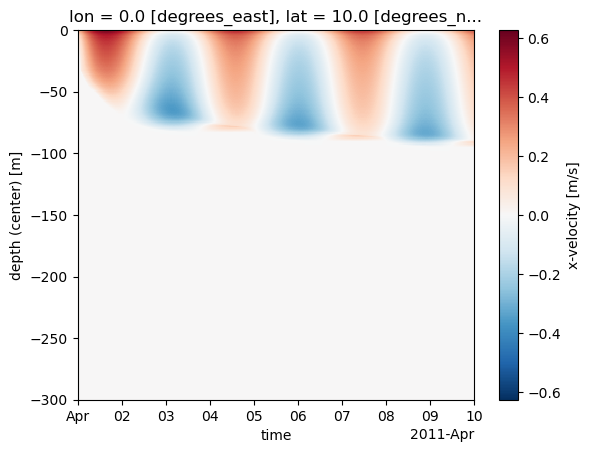

In [8]:
ds.u.T.plot()

In [13]:
from itertools import product
for i, combo in enumerate(product([0,1], [10,20], [2,3], [30,40])):
    print(i, combo)

0 (0, 10, 2, 30)
1 (0, 10, 2, 40)
2 (0, 10, 3, 30)
3 (0, 10, 3, 40)
4 (0, 20, 2, 30)
5 (0, 20, 2, 40)
6 (0, 20, 3, 30)
7 (0, 20, 3, 40)
8 (1, 10, 2, 30)
9 (1, 10, 2, 40)
10 (1, 10, 3, 30)
11 (1, 10, 3, 40)
12 (1, 20, 2, 30)
13 (1, 20, 2, 40)
14 (1, 20, 3, 30)
15 (1, 20, 3, 40)


In [16]:
np.arange(-100,125,25).tolist()

[-100, -75, -50, -25, 0, 25, 50, 75, 100]

In [3]:
MLD = 32
DEPTH = 300

t_profile = np.empty(DEPTH)
t_profile[0:MLD] = 29.25
t_profile[MLD:] = 29.25 - 0.04*np.arange(1,DEPTH-MLD+1,1)

In [116]:
start = - DEPTH + 0.5
end = 0.5

z_levels = np.arange(start,end,1)[::-1]

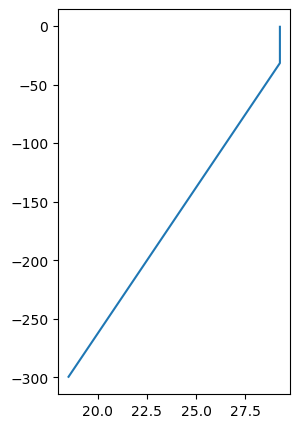

In [117]:
plt.figure(figsize=(3,5))
plt.plot(t_profile, z_levels)

In [123]:
def generate_time_range(start, end, delta):
    current_date = start
    while current_date < end:
        yield current_date
        current_date += timedelta(days=delta)

In [124]:
start = datetime(2011, 4, 1)
end = datetime(2011, 4, 5)
delta = 1
date_list = list(generate_time_range(start, end, delta))

In [125]:
with open("/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/MOM6_SCM_Hurr/analysis/compare_with_GOTM/cases/t_prof.dat", "w", encoding='utf-8') as file:
    for date in date_list:
        data_string_list = [f"{z}\t{t}" for z, t in zip(z_levels,t_profile)]
        data_string = "\n".join(data_string_list)
        file.write(f"{str(date)}\t{DEPTH}\t{2}\n{data_string}\n")

In [1]:
import yaml

In [2]:
with open('/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/MOM6_SCM_Hurr/analysis/compare_with_GOTM/cases/gotm.yaml', 'r') as file:
    data = yaml.safe_load(file)

In [5]:
data['surface']['fluxes']['tx']['file']

'/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/MOM6_SCM_Hurr/analysis/compare_with_GOTM/forcing/10/momentumflux046.dat'

In [4]:
from run_gotm_cases import run_gotm_cases

In [6]:
run_gotm_cases(
    root_dir="/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/MOM6_SCM_Hurr/analysis/compare_with_GOTM",
    source_dir_name="cases",
    forcing_dir_name="forcing",
    case_dict={('05', '46'): "TC021"}
)

sh: gotm: command not found


In [7]:
import re

In [ ]:
tau_file_pattern = re.compile(r'^(?P<indent>file:\s+tau_file.dat')

re.compile(r'^(?P<indent>\s*)file:\stau_file.dat', re.UNICODE)

In [20]:
with open("/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/MOM6_SCM_Hurr/analysis/compare_with_GOTM/cases/gotm_copy.yaml", 'r') as file:
    lines = file.readlines()

new_lines = []
tau_file_pattern = re.compile(r'^(?P<indent>\s*)file:\s+tau_file.dat')

for line in lines:
    tau_match = tau_file_pattern.match(line)

    if tau_match:
        indent = tau_match.group('indent')
        new_line = (f"{indent}file: test_filename.dat\n")
        new_lines.append(new_line)
        continue
    
    new_lines.append(line)

with open("/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/MOM6_SCM_Hurr/analysis/compare_with_GOTM/cases/gotm_copy.yaml", 'w') as file:
    file.writelines(new_lines)